# AI Jobs & AI Agent Workforce — 10-Part Analysis
 Two datasets:
- `global_ai_jobs_2026_CLEANED.csv`
- `Global_AI_Agent_Workforce_Integration_2026_CLEANED.csv`

# Loading the libraries 

In [31]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score

jobs = pd.read_csv('global_ai_jobs_2026_CLEANED.csv')
agents = pd.read_csv('Global_AI_Agent_Workforce_Integration_2026_CLEANED.csv')

print(jobs.shape, agents.shape)
jobs.head()

(5000, 37) (2500, 13)


,Job_ID,Job_Title,AI_Specialization,Industry,Company,Company_Size,Country,Continent,Education_Required,Experience_Level,...,Work_Life_Balance_1_10,AI_Investment_Company_Millions,Company_AI_Maturity_1_10,Job_Growth_Projection_%,Automation_Risk_%,Gender_Diversity_%_Female,Posted_Date,Application_Deadline,Record_Created,Data_Source
0,AI-03546,Business Intelligence Analyst,Computer Vision,E-commerce,Alibaba,Enterprise (5000+),Israel,Asia,Bachelor's,Executive,...,5.2,39,3.9,30.7,10.2,22.7,2035-09-16,2035-10-17,2026-08-28,Global AI Jobs Report 2026
1,AI-01969,Generative AI Engineer,Reinforcement Learning,Automotive,UiPath,Large (501-5000),United States,North America,Master's,Executive,...,7.3,499,3.9,18.1,20.7,39.8,2031-05-23,2031-06-23,2026-08-28,Global AI Jobs Report 2026
2,AI-02960,AI Software Engineer,Deep Learning,Insurance,UiPath,Enterprise (5000+),United States,North America,Postdoctoral,Executive,...,5.5,5,2.8,43.7,29.1,27.1,2034-02-07,2034-03-10,2026-08-28,Global AI Jobs Report 2026
3,AI-02384,NLP Engineer,Other,Transportation,Adobe,Large (501-5000),United States,North America,PhD,Executive,...,4.7,172,8.1,39.9,24.9,15.9,2032-07-11,2032-08-11,2026-08-28,Global AI Jobs Report 2026
4,AI-03930,AI Solutions Architect,Reinforcement Learning,Cloud Computing,Megvii,Large (501-5000),Switzerland,Europe,PhD,Executive,...,8.1,65,6.8,25.6,31.5,41.2,2036-10-04,2036-11-04,2026-08-28,Global AI Jobs Report 2026


# 1. Basic schema & missing value check

In [32]:
print("JOBS DTYPES")
print(jobs.dtypes)
print()
print("JOBS NULLS")
print(jobs.isnull().sum()[jobs.isnull().sum() > 0])
print()
print("AGENTS DTYPES")
print(agents.dtypes)
print()
print("AGENTS NULLS")
print(agents.isnull().sum().sum(), "total nulls")

JOBS DTYPES
Job_ID                             object
Job_Title                          object
AI_Specialization                  object
Industry                           object
Company                            object
Company_Size                       object
Country                            object
Continent                          object
Education_Required                 object
Experience_Level                   object
Years_of_Experience                 int64
Salary_USD                        float64
Salary_Min                          int64
Salary_Max                          int64
Salary_Category                    object
Bonus_%                           float64
Equity_Offered                     object
Benefits_Value_USD                  int64
Skills_Required                    object
Required_Certifications            object
Job_Openings                        int64
Competition_Level_Applicants        int64
Hiring_Difficulty_1_10            float64
Job_Type              

# 2. Descriptive stats (numeric columns)

In [33]:
print(jobs.describe().T)
print()
print(agents.describe().T)

                                 count          mean            std      min  \
Years_of_Experience             5000.0       7.57540       6.245263      0.0   
Salary_USD                      5000.0  158179.95840   78886.439234  27934.0   
Salary_Min                      5000.0  126656.83140   63920.017903  21398.0   
Salary_Max                      5000.0  197920.70540  100139.163004  34852.0   
Bonus_%                         5000.0      17.33884       7.238298      5.0   
Benefits_Value_USD              5000.0   22363.49640   10110.624917   5002.0   
Job_Openings                    5000.0      10.07360       3.210209      1.0   
Competition_Level_Applicants    5000.0     257.89520     141.564460     10.0   
Hiring_Difficulty_1_10          5000.0       6.30412       1.884440      3.0   
Remote_Work_%                   5000.0      57.74800      26.115606      0.0   
Job_Satisfaction_1_10           5000.0       7.51072       1.153455      5.5   
Work_Life_Balance_1_10          5000.0  

## 3. Average Salary by Country and Experience Level

In [34]:
salary_by_country = jobs.groupby('Country')['Salary_USD'].mean().sort_values(ascending=False)
print(salary_by_country.head(10))

salary_by_exp = jobs.groupby('Experience_Level')['Salary_USD'].mean().sort_values(ascending=False)
print(salary_by_exp)

Country
Switzerland       229421.711712
United States     227574.706422
Singapore         221727.643836
Germany           210996.907216
Israel            200961.186667
Canada            194068.990099
Netherlands       191180.917526
Australia         191009.371429
United Kingdom    177266.242718
Egypt             170358.285714
Name: Salary_USD, dtype: float64
Experience_Level
Executive       347622.671533
Lead Level      218003.512101
Senior Level    156035.647587
Mid Level       109655.904628
Entry Level      74285.995876
Name: Salary_USD, dtype: float64


## 4. Correlation heatmap (numeric features) — Jobs dataset

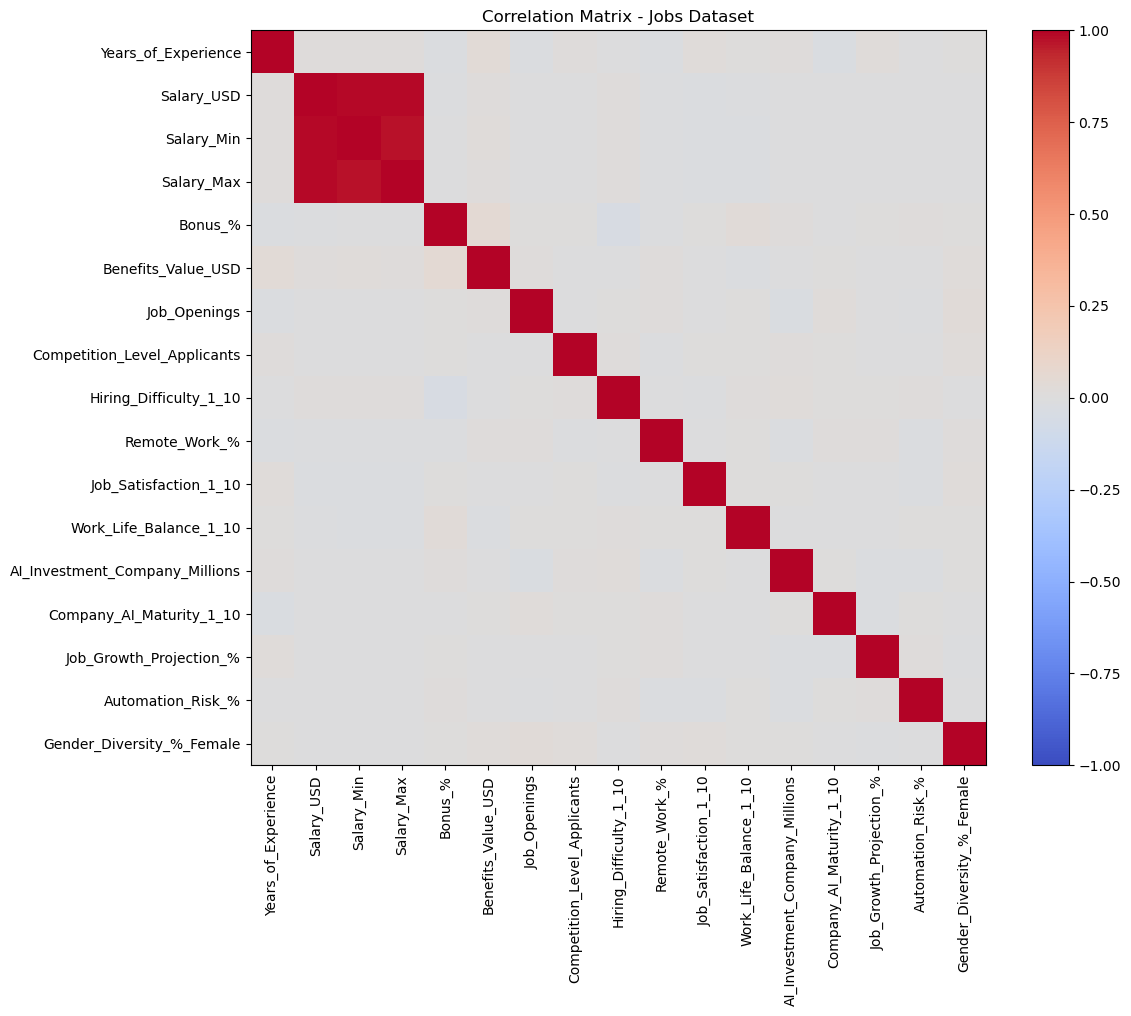

In [35]:
num_jobs = jobs.select_dtypes(include=[np.number])
corr = num_jobs.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Correlation Matrix - Jobs Dataset')
plt.tight_layout()
plt.show()

## 5. Feature engineering: skill count, boolean flags, date parsing

In [36]:
jobs['Num_Skills'] = jobs['Skills_Required'].str.split(',').apply(len)
jobs['Has_Certification'] = jobs['Required_Certifications'].notnull().astype(int)
jobs['Equity_Flag'] = (jobs['Equity_Offered'] == 'Yes').astype(int)
jobs['WFH_Flag'] = (jobs['Work_From_Home_Available'] == 'Yes').astype(int)

jobs['Posted_Date'] = pd.to_datetime(jobs['Posted_Date'])
jobs['Application_Deadline'] = pd.to_datetime(jobs['Application_Deadline'])
jobs['Days_To_Apply'] = (jobs['Application_Deadline'] - jobs['Posted_Date']).dt.days

jobs[['Num_Skills', 'Has_Certification', 'Equity_Flag', 'WFH_Flag', 'Days_To_Apply']].head()

,Num_Skills,Has_Certification,Equity_Flag,WFH_Flag,Days_To_Apply
0,6,1,0,1,31
1,6,1,0,0,31
2,6,0,1,1,31
3,6,1,0,1,31
4,6,1,0,0,31


## 6. XGBoost Regression — Predict Salary_USD

In [37]:
df = jobs.drop(columns=['Job_ID', 'Salary_Min', 'Salary_Max', 'Salary_Category',
                         'Data_Source', 'Posted_Date', 'Application_Deadline',
                         'Record_Created', 'Skills_Required', 'Required_Certifications',
                         'Equity_Offered', 'Work_From_Home_Available'])

cat_cols = df.select_dtypes(include='object').columns.tolist()
for c in cat_cols:
    df[c] = df[c].astype('category').cat.codes

X = df.drop(columns=['Salary_USD'])
y = df['Salary_USD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)
reg_model.fit(X_train, y_train)

pred = reg_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))
print("RMSE:", rmse)
print("Mean Salary:", y.mean())
print("RMSE as % of mean salary:", round(rmse / y.mean() * 100, 2), "%")


RMSE: 40710.82747270447
Mean Salary: 158179.9584
RMSE as % of mean salary: 25.74 %


## 9. XGBoost Regression — Predict Automation_Risk_% (jobs dataset)

In [38]:
df3 = jobs.drop(columns=['Job_ID', 'Salary_Category', 'Data_Source', 'Posted_Date',
                          'Application_Deadline', 'Record_Created', 'Skills_Required',
                          'Required_Certifications', 'Equity_Offered', 'Work_From_Home_Available'])

cat_cols3 = df3.select_dtypes(include='object').columns.tolist()
for c in cat_cols3:
    df3[c] = df3[c].astype('category').cat.codes

X3 = df3.drop(columns=['Automation_Risk_%'])
y3 = df3['Automation_Risk_%']

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

risk_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)
risk_model.fit(X3_train, y3_train)

risk_pred = risk_model.predict(X3_test)
rmse3 = np.sqrt(mean_squared_error(y3_test, risk_pred))
print("RMSE (Automation Risk %):", rmse3)

imp3 = pd.Series(risk_model.feature_importances_, index=X3.columns).sort_values(ascending=False)
print(imp3.head(10))

RMSE (Automation Risk %): 10.381712021033026
Has_Certification               0.041902
Hiring_Difficulty_1_10          0.040911
Job_Type                        0.040751
Competition_Level_Applicants    0.040258
Equity_Flag                     0.039292
Gender_Diversity_%_Female       0.039275
Job_Growth_Projection_%         0.039156
Salary_Max                      0.038713
Company_AI_Maturity_1_10        0.038645
Years_of_Experience             0.038030
dtype: float32


## 10. Agent dataset: Productivity Gain by Industry & Governance, plus ROI regression

In [40]:
prod_by_industry = agents.groupby('Industry')['Productivity_Gain_Percent'].mean().sort_values(ascending=False)
print(prod_by_industry)
print()

prod_by_gov = agents.groupby('Has_Strict_AI_Governance')['Productivity_Gain_Percent'].mean()
print(prod_by_gov)
print()

# Predict Months_To_Positive_ROI
cat_cols2 = ['Industry', 'Company_Size', 'Primary_AI_Agent_Role']  # <-- defined here now

df4 = agents.copy()
for c in cat_cols2:
    df4[c] = df4[c].astype('category').cat.codes
df4['Has_Strict_AI_Governance'] = df4['Has_Strict_AI_Governance'].astype(int)

X4 = df4.drop(columns=['Company_ID', 'Months_To_Positive_ROI'])
y4 = df4['Months_To_Positive_ROI']

X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=42)

roi_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42)
roi_model.fit(X4_train, y4_train)

roi_pred = roi_model.predict(X4_test)
rmse4 = np.sqrt(mean_squared_error(y4_test, roi_pred))
print("RMSE (Months to Positive ROI):", rmse4)

Industry
Education        33.473420
Manufacturing    33.086955
Retail           32.996630
Finance          32.622968
Healthcare       32.470398
Logistics        32.420368
Technology       32.026070
Name: Productivity_Gain_Percent, dtype: float64

Has_Strict_AI_Governance
False    33.094682
True     32.479589
Name: Productivity_Gain_Percent, dtype: float64

RMSE (Months to Positive ROI): 10.677345958804953
